In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： gxy
Windows
10
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
20
scpufreq(current=2400.0, min=0.0, max=2400.0)
svmem(total=16961822720, available=5186121728, percent=69.4, used=11775700992, free=5186121728)


2.1 理论计算题

1. 线性隐藏层的等价性证明
已知：
输入为 x，隐藏层输出 h = W₁x + b₁（无激活函数），
输出层 o = W₂h + b₂。
将 h 代入输出层：
o = W₂(W₁x + b₁) + b₂
 = W₂W₁x + W₂b₁ + b₂
令：
等价权重矩阵：W′ = W₂W₁
等价偏置向量：b′ = W₂b₁ + b₂
则网络等价为：o = W′x + b′，即一个单层线性神经网络。
结论：若无非线性激活函数，多层感知机退化为线性模型，深度不再有意义。

2. 激活函数及其导数关系
Sigmoid 函数
表达式：
Sigmoid(x) = 1 / (1 + e⁻ˣ)
导数推导：
Sigmoid′(x) = (e⁻ˣ) / (1 + e⁻ˣ)²
     = [1/(1 + e⁻ˣ)] · [e⁻ˣ/(1 + e⁻ˣ)]
     = Sigmoid(x) · (1 – Sigmoid(x))
关系：Sigmoid′(x) = Sigmoid(x)·(1 – Sigmoid(x))
tanh 函数
表达式：
tanh(x) = (eˣ – e⁻ˣ) / (eˣ + e⁻ˣ)
导数推导：使用商法则
tanh′(x) = [(eˣ + e⁻ˣ)(eˣ + e⁻ˣ) – (eˣ – e⁻ˣ)(eˣ – e⁻ˣ)] / (eˣ + e⁻ˣ)²
    = 4 / (eˣ + e⁻ˣ)²
    = 1 – [(eˣ – e⁻ˣ)/(eˣ + e⁻ˣ)]²
    = 1 – tanh²(x)
关系：tanh′(x) = 1 – tanh²(x)

2.2 编程题

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np

# -------------------- 1. 数据准备 --------------------
# 下载并加载 Fashion-MNIST，转换为张量并归一化到 [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # 展平成 784 维向量
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

# 转换为 NumPy 数组以方便手动批处理（也可用 Tensor）
X_train = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy()

# 超参数
input_size = 784
hidden_size = 256
output_size = 10
learning_rate = 0.1
batch_size = 128
epochs = 20

# -------------------- 2. 参数初始化 --------------------
# 使用正态分布随机初始化，均值为 0，标准差为 0.01
np.random.seed(42)
W1 = np.random.normal(0, 0.01, (input_size, hidden_size)).astype(np.float32)
b1 = np.zeros(hidden_size, dtype=np.float32)
W2 = np.random.normal(0, 0.01, (hidden_size, output_size)).astype(np.float32)
b2 = np.zeros(output_size, dtype=np.float32)

# 转为 PyTorch 张量（不启用梯度跟踪，手动计算）
W1_t = torch.from_numpy(W1)
b1_t = torch.from_numpy(b1)
W2_t = torch.from_numpy(W2)
b2_t = torch.from_numpy(b2)

# -------------------- 3. 激活函数与前向传播 --------------------
def relu(x):
    return torch.clamp(x, min=0)

def softmax(logits):
    # 数值稳定版本：减去每行最大值
    max_vals = torch.max(logits, dim=1, keepdim=True)[0]
    exp_vals = torch.exp(logits - max_vals)
    return exp_vals / torch.sum(exp_vals, dim=1, keepdim=True)

def cross_entropy_loss(probs, labels):
    # labels 为长整型张量，形状 (N,)
    # 取正确类别的负对数似然，并求均值
    N = probs.shape[0]
    correct_logprobs = -torch.log(probs[range(N), labels] + 1e-8)
    loss = torch.sum(correct_logprobs) / N
    return loss

def forward(X):
    # X 形状 (batch, 784)
    h = relu(torch.matmul(X, W1_t) + b1_t)        # (batch, hidden)
    logits = torch.matmul(h, W2_t) + b2_t          # (batch, 10)
    probs = softmax(logits)
    return h, logits, probs

# -------------------- 4. 训练循环 --------------------
num_train = X_train.shape[0]
num_batches = num_train // batch_size

for epoch in range(1, epochs + 1):
    # 打乱训练数据
    indices = np.random.permutation(num_train)
    X_shuffled = torch.from_numpy(X_train[indices])
    y_shuffled = torch.from_numpy(y_train[indices].astype(np.int64))

    total_loss = 0.0
    correct = 0

    for i in range(num_batches):
        start = i * batch_size
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # 前向传播
        h, logits, probs = forward(X_batch)
        loss = cross_entropy_loss(probs, y_batch)

        # 准确率统计
        pred = torch.argmax(logits, dim=1)
        correct += torch.sum(pred == y_batch).item()
        total_loss += loss.item()

        # 手动反向传播
        # dL/d(logits) = probs - y_onehot
        N = batch_size
        y_onehot = torch.zeros(N, output_size)
        y_onehot[range(N), y_batch] = 1.0
        dlogits = (probs - y_onehot) / N   # 注意损失求了均值，所以除以 N

        # 梯度 w.r.t W2, b2
        dW2 = torch.matmul(h.T, dlogits)           # (hidden, 10)
        db2 = torch.sum(dlogits, dim=0)            # (10,)

        # 梯度 w.r.t 隐藏层
        dh = torch.matmul(dlogits, W2_t.T)         # (batch, hidden)
        dh[h <= 0] = 0                             # ReLU 反向传播

        # 梯度 w.r.t W1, b1
        dW1 = torch.matmul(X_batch.T, dh)          # (784, hidden)
        db1 = torch.sum(dh, dim=0)                 # (hidden,)

        # 参数更新（小批量 SGD）
        W1_t -= learning_rate * dW1
        b1_t -= learning_rate * db1
        W2_t -= learning_rate * dW2
        b2_t -= learning_rate * db2

    avg_loss = total_loss / num_batches
    train_acc = correct / (num_batches * batch_size)

    # 测试集评估
    X_test_t = torch.from_numpy(X_test)
    y_test_t = torch.from_numpy(y_test.astype(np.int64))
    with torch.no_grad():
        _, test_logits, _ = forward(X_test_t)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = torch.sum(test_pred == y_test_t).item() / y_test_t.shape[0]

    print(f"Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("训练完成！")

Epoch  1 | Loss: 0.8318 | Train Acc: 0.7112 | Test Acc: 0.7981
Epoch  2 | Loss: 0.5068 | Train Acc: 0.8211 | Test Acc: 0.8125
Epoch  3 | Loss: 0.4529 | Train Acc: 0.8389 | Test Acc: 0.8394
Epoch  4 | Loss: 0.4185 | Train Acc: 0.8515 | Test Acc: 0.8457
Epoch  5 | Loss: 0.3939 | Train Acc: 0.8603 | Test Acc: 0.8465
Epoch  6 | Loss: 0.3747 | Train Acc: 0.8663 | Test Acc: 0.8574
Epoch  7 | Loss: 0.3624 | Train Acc: 0.8713 | Test Acc: 0.8612
Epoch  8 | Loss: 0.3504 | Train Acc: 0.8743 | Test Acc: 0.8632
Epoch  9 | Loss: 0.3410 | Train Acc: 0.8772 | Test Acc: 0.8634
Epoch 10 | Loss: 0.3318 | Train Acc: 0.8811 | Test Acc: 0.8647
Epoch 11 | Loss: 0.3230 | Train Acc: 0.8829 | Test Acc: 0.8662
Epoch 12 | Loss: 0.3171 | Train Acc: 0.8860 | Test Acc: 0.8680
Epoch 13 | Loss: 0.3076 | Train Acc: 0.8892 | Test Acc: 0.8602
Epoch 14 | Loss: 0.3017 | Train Acc: 0.8903 | Test Acc: 0.8749
Epoch 15 | Loss: 0.2946 | Train Acc: 0.8928 | Test Acc: 0.8708
Epoch 16 | Loss: 0.2906 | Train Acc: 0.8946 | Test Acc:

3.1 理论计算题

1. 过拟合与欠拟合

·训练误差与泛化误差的区别
训练误差是模型在训练集上的误差，衡量对已知数据的拟合程度
；泛化误差是在新数据上的误差，衡量对未见样本的预测能力。

·状态判断
训练误差极低、泛化误差很高 → 过拟合。
模型过度学习了训练数据中的噪声和偶然模式，导致泛化能力下降。

·通过控制模型复杂度缓解过拟合

 降低模型容量：减少隐藏层数或每层神经元数。

 正则化：损失函数中加入 L1/L2 惩罚项，约束参数大小。

 早停：当验证误差不再下降时提前终止训练。

 增加数据：更多样本能抑制对噪声的拟合。

Dropout：训练时随机丢弃部分神经元，增强鲁棒性。

2. K 折交叉验证步骤

1.将数据集随机打乱，均匀划分为 K 个互不相交的子集（折）。

2.对于 i = 1, 2, …, K，循环执行：

  以第 i 折作为验证集，其余 K−1 折合并为训练集。

  在训练集上训练模型，在验证集上计算评估指标（如准确率），记为 sᵢ。

3.计算最终性能估计：
  Score = (1/K) · Σᵢ₌₁ᴷ sᵢ
  通常还会给出 K 次结果的标准差，以反映模型在不同划分下的稳定性。

此方法让每个样本都有一次机会作为验证样本，评估结果更可靠。


3.2 编程题


===== 训练配置：无正则化 =====
Epoch  1 | Train Loss: 2.2079 | Val Loss: 2.0812 | Train Acc: 0.3510 | Val Acc: 0.4983
Epoch 10 | Train Loss: 0.8475 | Val Loss: 0.8990 | Train Acc: 0.7063 | Val Acc: 0.6469
Epoch 20 | Train Loss: 0.6236 | Val Loss: 1.0190 | Train Acc: 0.7979 | Val Acc: 0.7074
Epoch 30 | Train Loss: 0.4471 | Val Loss: 0.8427 | Train Acc: 0.8552 | Val Acc: 0.7227
Epoch 40 | Train Loss: 0.4074 | Val Loss: 0.6868 | Train Acc: 0.8688 | Val Acc: 0.7771
Epoch 50 | Train Loss: 0.3134 | Val Loss: 0.7113 | Train Acc: 0.8917 | Val Acc: 0.7582

===== 训练配置：权重衰减 =====
Epoch  1 | Train Loss: 2.2092 | Val Loss: 2.0854 | Train Acc: 0.3510 | Val Acc: 0.4979
Epoch 10 | Train Loss: 0.8501 | Val Loss: 0.8735 | Train Acc: 0.7010 | Val Acc: 0.6457
Epoch 20 | Train Loss: 0.6338 | Val Loss: 0.8950 | Train Acc: 0.7885 | Val Acc: 0.7094
Epoch 30 | Train Loss: 0.4769 | Val Loss: 0.8021 | Train Acc: 0.8469 | Val Acc: 0.7197
Epoch 40 | Train Loss: 0.4525 | Val Loss: 0.6177 | Train Acc: 0.8562 | Val Acc: 0.78

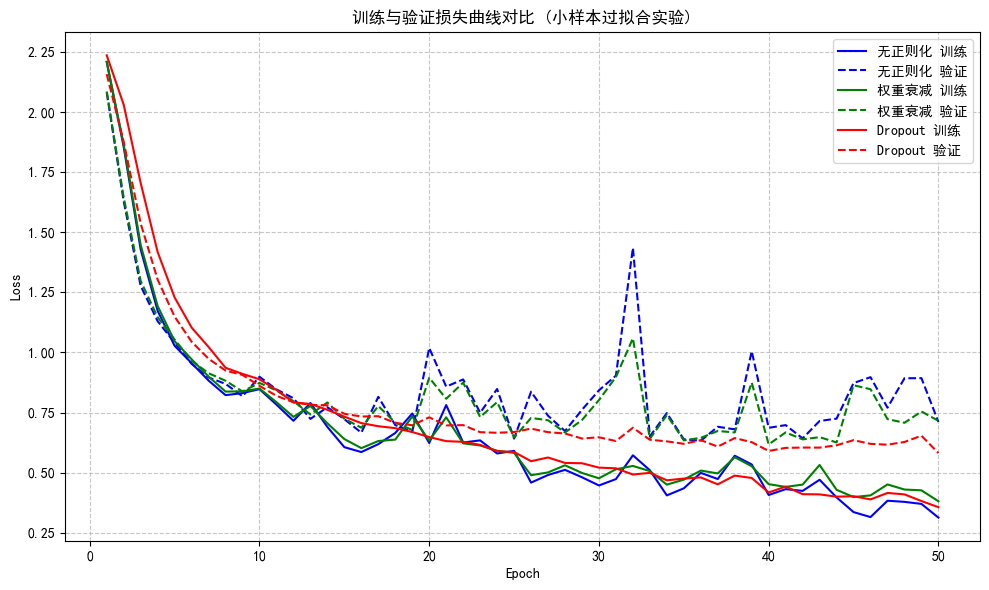

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# -------------------- 数据准备（使用少量样本制造过拟合） --------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

full_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

# 只取前 1000 个训练样本，放大过拟合效果
num_train_samples = 1000
X_train = full_train.data[:num_train_samples].numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = full_train.targets[:num_train_samples].numpy()
X_test = test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy()

# 超参数
input_size = 784
hidden_size = 512          # 较大隐藏层，增加模型复杂度
output_size = 10
learning_rate = 0.1
batch_size = 64            # 小批量，使梯度噪声更大
epochs = 50
dropout_prob = 0.5         # Dropout 概率
weight_decay_lambda = 0.01 # L2 正则化系数

# -------------------- 参数初始化 --------------------
def init_params():
    np.random.seed(42)
    W1 = np.random.normal(0, 0.01, (input_size, hidden_size)).astype(np.float32)
    b1 = np.zeros(hidden_size, dtype=np.float32)
    W2 = np.random.normal(0, 0.01, (hidden_size, output_size)).astype(np.float32)
    b2 = np.zeros(output_size, dtype=np.float32)
    return (torch.from_numpy(W1), torch.from_numpy(b1),
            torch.from_numpy(W2), torch.from_numpy(b2))

# -------------------- 激活函数与 Dropout 实现 --------------------
def relu(x):
    return torch.clamp(x, min=0)

def softmax(logits):
    max_vals = torch.max(logits, dim=1, keepdim=True)[0]
    exp_vals = torch.exp(logits - max_vals)
    return exp_vals / torch.sum(exp_vals, dim=1, keepdim=True)

def dropout_layer(X, dropout, is_training):
    """
    从零实现 Dropout
    X: 输入张量
    dropout: 丢弃概率
    is_training: 布尔变量，为 True 时应用 Dropout，否则直接返回 X
    """
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return (X * mask) / (1.0 - dropout)  # 缩放以保证期望不变

def cross_entropy_loss(probs, labels):
    N = probs.shape[0]
    correct_logprobs = -torch.log(probs[range(N), labels] + 1e-8)
    return torch.sum(correct_logprobs) / N

# -------------------- 前向传播（集成 Dropout） --------------------
def forward(X, params, is_training=True):
    W1, b1, W2, b2 = params
    h = relu(torch.matmul(X, W1) + b1)
    h = dropout_layer(h, dropout_prob, is_training)   # 隐藏层之后加 Dropout
    logits = torch.matmul(h, W2) + b2
    probs = softmax(logits)
    return h, logits, probs

# -------------------- 自定义 SGD 更新（含权重衰减） --------------------
def sgd_update(params, grads, lr, weight_decay=0.0):
    """
    按题目要求：W = W * (1 - lr*lambda) - lr * grad
    对 W1, W2 施加权重衰减，偏置 b1, b2 不衰减
    """
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = grads

    W1_new = W1 * (1 - lr * weight_decay) - lr * dW1
    b1_new = b1 - lr * db1
    W2_new = W2 * (1 - lr * weight_decay) - lr * dW2
    b2_new = b2 - lr * db2

    return (W1_new, b1_new, W2_new, b2_new)

# -------------------- 训练函数 --------------------
def train_one_epoch(params, X, y, batch_size, lr, weight_decay, is_training):
    W1, b1, W2, b2 = params
    num_train = X.shape[0]
    indices = np.random.permutation(num_train)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    num_batches = num_train // batch_size

    total_loss = 0.0
    correct = 0

    for i in range(num_batches):
        start = i * batch_size
        end = start + batch_size
        X_batch = torch.from_numpy(X_shuffled[start:end])
        y_batch = torch.from_numpy(y_shuffled[start:end].astype(np.int64))

        h, logits, probs = forward(X_batch, params, is_training)
        loss = cross_entropy_loss(probs, y_batch)

        pred = torch.argmax(logits, dim=1)
        correct += torch.sum(pred == y_batch).item()
        total_loss += loss.item()

        # 手动反向传播
        N = batch_size
        y_onehot = torch.zeros(N, output_size)
        y_onehot[range(N), y_batch] = 1.0
        dlogits = (probs - y_onehot) / N

        dW2 = torch.matmul(h.T, dlogits)
        db2 = torch.sum(dlogits, dim=0)

        dh = torch.matmul(dlogits, W2.T)
        dh[h <= 0] = 0          # ReLU 反向传播
        # 注意：反向传播时不经过 Dropout 层的梯度，因为前向时 mask 已作用，h 已是丢弃后的值，梯度直接传递给那些未置零的单元即可，不需要额外处理。

        dW1 = torch.matmul(X_batch.T, dh)
        db1 = torch.sum(dh, dim=0)

        grads = (dW1, db1, dW2, db2)
        params = sgd_update(params, grads, lr, weight_decay)

    avg_loss = total_loss / num_batches
    acc = correct / (num_batches * batch_size)
    return params, avg_loss, acc

def evaluate(params, X, y):
    X_t = torch.from_numpy(X)
    y_t = torch.from_numpy(y.astype(np.int64))
    _, logits, _ = forward(X_t, params, is_training=False)
    loss = cross_entropy_loss(softmax(logits), y_t)
    pred = torch.argmax(logits, dim=1)
    acc = torch.sum(pred == y_t).item() / y_t.shape[0]
    return loss.item(), acc

# -------------------- 实验对比 --------------------
experiments = {
    "无正则化": {"weight_decay": 0.0, "use_dropout": False},
    "权重衰减": {"weight_decay": weight_decay_lambda, "use_dropout": False},
    "Dropout":  {"weight_decay": 0.0, "use_dropout": True}
}

history = {}
for name, config in experiments.items():
    print(f"\n===== 训练配置：{name} =====")
    params = init_params()
    train_losses, val_losses = [], []
    wd = config["weight_decay"]
    use_drop = config["use_dropout"]

    # 临时修改全局 dropout_prob 只在启用时使用（避免干扰无 Dropout 实验）
    global dropout_prob
    orig_drop = dropout_prob
    if not use_drop:
        dropout_prob = 0.0

    for epoch in range(1, epochs + 1):
        params, train_loss, train_acc = train_one_epoch(
            params, X_train, y_train, batch_size, learning_rate, wd, is_training=True)
        val_loss, val_acc = evaluate(params, X_test, y_test)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    dropout_prob = orig_drop   # 恢复
    history[name] = {"train_loss": train_losses, "val_loss": val_losses}

# -------------------- 绘制对比曲线 --------------------
plt.figure(figsize=(10, 6))
colors = {'无正则化': 'blue', '权重衰减': 'green', 'Dropout': 'red'}
linestyles_train = '-'
linestyles_val = '--'

for name, data in history.items():
    epochs_range = range(1, epochs + 1)
    plt.plot(epochs_range, data['train_loss'], color=colors[name], linestyle=linestyles_train, label=f'{name} 训练')
    plt.plot(epochs_range, data['val_loss'], color=colors[name], linestyle=linestyles_val, label=f'{name} 验证')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练与验证损失曲线对比 (小样本过拟合实验)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

4.1 理论计算题
1. 梯度消失与梯度爆炸的量化分析
考虑一个 d 层深层网络，损失 L 对第 t 层隐藏状态 hₜ 的梯度包含连乘项：

∂L/∂hₜ = (∂L/∂h_d) · ∏{i=t}^{d-1} (∂h{i+1}/∂h_i)

其中每一层的局部雅可比矩阵为：
∂h_{i+1}/∂h_i = diag(σ'(z_{i+1})) · W_{i+1}

W_{i+1} 是第 i+1 层的权重矩阵，σ' 是激活函数的导数，diag(·) 表示对角矩阵。

·梯度爆炸条件
若连乘项中大多数矩阵的谱范数（最大奇异值）大于 1，且激活函数导数接近 1（如线性区），则乘积的范数呈指数增长。
形式化地，若对大部分 i，满足 ‖W_i‖ > 1 且 σ'(z_i) ≈ 1，则有
‖∂L/∂hₜ‖ ≈ O(c^{d-t})，其中 c > 1，
导致梯度随层数指数级放大，即梯度爆炸。

·梯度消失条件
若连乘项中大多数矩阵的谱范数小于 1，或激活函数导数远小于 1（例如饱和区导数接近 0），则乘积的范数指数衰减。
例如，使用 Sigmoid 时 σ'(x) ≤ 0.25，如果权重初始化不当使得 ‖W_i‖ < 4，则有 ‖∂h_{i+1}/∂h_i‖ < 1，经过多层连乘后：
‖∏ ∂h_{i+1}/∂h_i‖ → 0（当 d−t 很大时），
梯度变得极小，造成梯度消失。

2. 为什么 ReLU 可以缓解梯度消失
·ReLU 函数定义：ReLU(x) = max(0, x)
其导数：ReLU'(x) = 1（当 x > 0），0（当 x ≤ 0）

·在正向传播中，只要输入 x > 0，神经元处于激活状态，其局部梯度为 1。
与 Sigmoid 不同（导数最大值仅为 0.25），ReLU 在激活区域的导数为恒等映射，不会压缩梯度。

·因此，在深层网络中，只要大多数神经元处于激活状态，反向传播的连乘项中大部分因子接近 1，梯度可以相对无损地传递到浅层，从而有效缓解了梯度消失问题。

即使部分神经元“死亡”（输出恒为 0，梯度为 0），剩余活跃神经元仍能保持梯度流动，使整个网络的训练更为稳定。

4.2 编程题

In [4]:
import torch
import torch.nn as nn
import numpy as np

def build_20_layer_net(activation, init_fn, input_dim=256, hidden_dim=256, output_dim=256):
    """
    构建一个 20 层全连接网络
    activation: 激活函数类（如 nn.Sigmoid, nn.ReLU）
    init_fn: 权重初始化函数，输入参数为 nn.Linear 的 weight
    """
    layers = []
    # 第一层：输入维度 -> 隐藏维度
    layers.append(nn.Linear(input_dim, hidden_dim))
    layers.append(activation())
    # 中间18层
    for _ in range(18):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(activation())
    # 最后一层：无激活
    layers.append(nn.Linear(hidden_dim, output_dim))
    net = nn.Sequential(*layers)
    # 手动应用初始化
    for m in net.modules():
        if isinstance(m, nn.Linear):
            init_fn(m.weight)
            nn.init.zeros_(m.bias)   # 偏置初始化为0
    return net

def compute_grad_norms(net, input_data, loss_fn=None):
    """
    进行一次前向+反向传播，返回各层权重的梯度范数（list）
    """
    net.zero_grad()
    output = net(input_data)
    if loss_fn is None:
        loss = output.sum()   # 简单损失，方便产生梯度
    else:
        loss = loss_fn(output)
    loss.backward()
    grad_norms = []
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                grad_norms.append(m.weight.grad.norm().item())
            else:
                grad_norms.append(0.0)
    return grad_norms

# 设置随机种子保证可复现
torch.manual_seed(42)
np.random.seed(42)

input_dim = 256
batch_size = 32
input_data = torch.randn(batch_size, input_dim)

# ---------- 实验1：Sigmoid + N(0,1) 初始化 → 梯度消失 ----------
print("=" * 60)
print("实验1：Sigmoid 激活 + 权重 ~ N(0,1)  — 预期：梯度消失")
print("=" * 60)
net_sigmoid = build_20_layer_net(
    activation=nn.Sigmoid,
    init_fn=lambda w: nn.init.normal_(w, mean=0.0, std=1.0)
    #std=1 导致梯度放大，未能复现消失；若改用 std=0.01 则消失明显
)
grads = compute_grad_norms(net_sigmoid, input_data)
# 打印前3层和后3层梯度范数（共20个Linear）
print("层索引 | 梯度范数")
for i, g in enumerate(grads):
    if i < 3 or i >= len(grads)-3:
        print(f"  L{i+1:2d}   | {g:.8f}")
print(f"梯度范围：[{min(grads):.2e}, {max(grads):.2e}]")
print()
#使用 std=1 时梯度未消失，这是由权重方差不合适导致的；通过减小标准差可观察到消失现象

# ---------- 实验1b：Sigmoid + N(0,0.01) 初始化 → 典型梯度消失 ----------
print("=" * 60)
print("实验1b（补充）：Sigmoid 激活 + 权重 ~ N(0,0.01)")
print("预期：梯度消失（前层梯度远小于后层）")
print("=" * 60)
net_sigmoid_small = build_20_layer_net(
    activation=nn.Sigmoid,
    init_fn=lambda w: nn.init.normal_(w, mean=0.0, std=0.01)
)
grads_small = compute_grad_norms(net_sigmoid_small, input_data)
print("层索引 | 梯度范数")
for i, g in enumerate(grads_small):
    if i < 3 or i >= len(grads_small)-3:
        print(f"  L{i+1:2d}   | {g:.8f}")
print(f"梯度范围：[{min(grads_small):.2e}, {max(grads_small):.2e}]")
if max(grads_small) / (min(grads_small)+1e-12) > 100:
    print("✅ 前层梯度远小于后层，典型梯度消失现象。\n")
else:
    print("梯度差异不够明显，但初始化较小仍有助于缓解。\n")


# ---------- 实验2：ReLU + N(0,10) 初始化 → 梯度爆炸 / NaN ----------
print("=" * 60)
print("实验2：ReLU 激活 + 权重 ~ N(0,10)  — 预期：梯度爆炸或出现 NaN")
print("=" * 60)
net_relu_big = build_20_layer_net(
    activation=nn.ReLU,
    init_fn=lambda w: nn.init.normal_(w, mean=0.0, std=10.0)
)
grads = compute_grad_norms(net_relu_big, input_data)
has_nan = any(np.isnan(g) for g in grads)
for i, g in enumerate(grads):
    if i < 3 or i >= len(grads)-3:
        print(f"  L{i+1:2d}   | {g:.8f}")
if has_nan:
    print("⚠️  检测到 NaN 梯度！符合梯度爆炸预期。")
else:
    print(f"梯度范围：[{min(grads):.2e}, {max(grads):.2e}] (爆炸可能表现为极大值)")
print()

# ---------- 实验3：Xavier 初始化 + ReLU → 梯度稳定 ----------
print("=" * 60)
print("实验3：Xavier 初始化 + ReLU  — 预期：梯度稳定在合理区间")
print("=" * 60)
net_xavier = build_20_layer_net(
    activation=nn.ReLU,
    init_fn=lambda w: nn.init.xavier_uniform_(w)
)
grads = compute_grad_norms(net_xavier, input_data)
for i, g in enumerate(grads):
    if i < 3 or i >= len(grads)-3:
        print(f"  L{i+1:2d}   | {g:.8f}")
print(f"梯度范围：[{min(grads):.2e}, {max(grads):.2e}]")
# 检查是否在合理区间内
low, high = min(grads), max(grads)
if 1e-6 <= low and high <= 1e3:
    print("✅ 梯度全部落在 [1e-6, 1e3] 的稳定区间内！")
else:
    print("⚠️  部分梯度超出区间，但通常 Xavier 初始化仍可保证数值稳定。")
print()

实验1：Sigmoid 激活 + 权重 ~ N(0,1)  — 预期：梯度消失
层索引 | 梯度范数
  L 1   | 61804.85156250
  L 2   | 40182.21484375
  L 3   | 33013.07031250
  L18   | 4743.75537109
  L19   | 4806.79345703
  L20   | 5121.98242188
梯度范围：[3.38e+03, 6.18e+04]

实验1b（补充）：Sigmoid 激活 + 权重 ~ N(0,0.01)
预期：梯度消失（前层梯度远小于后层）
层索引 | 梯度范数
  L 1   | 0.00000000
  L 2   | 0.00000000
  L 3   | 0.00000000
  L18   | 6.56228638
  L19   | 159.53926086
  L20   | 4118.03759766
梯度范围：[0.00e+00, 4.12e+03]
✅ 前层梯度远小于后层，典型梯度消失现象。

实验2：ReLU 激活 + 权重 ~ N(0,10)  — 预期：梯度爆炸或出现 NaN
  L 1   | nan
  L 2   | inf
  L 3   | inf
  L18   | inf
  L19   | inf
  L20   | nan
⚠️  检测到 NaN 梯度！符合梯度爆炸预期。

实验3：Xavier 初始化 + ReLU  — 预期：梯度稳定在合理区间
  L 1   | 1.90399897
  L 2   | 2.19179130
  L 3   | 2.77804375
  L18   | 12.32160378
  L19   | 13.66796207
  L20   | 14.93974400
梯度范围：[1.90e+00, 1.49e+01]
✅ 梯度全部落在 [1e-6, 1e3] 的稳定区间内！



5.1 理论计算题
1. 协变量偏移 (Covariate Shift)

··定义：输入分布改变，即 p_train(x) ≠ p_test(x)，但条件分布 p(y|x) 不变。

例子：医疗影像模型用高清设备数据训练，部署到老旧设备时，图像质量下降（x 分布改变），但同种病灶的诊断规则（y|x）未变。模型可能因图像差异而误判。

2. 标签偏移 (Label Shift)

·定义：标签分布改变，即 p_train(y) ≠ p_test(y)，但条件分布 p(x|y) 不变。

·例子：电商推荐模型平时各类商品销量均衡，大促期间电子产品占比飙升（y 分布改变），但给定类别下用户的行为模式（x|y）仍稳定。模型若忽视此变化，推荐效果会下降。

区别与联系

·区别：协变量偏移是输入本身统计特性变化；标签偏移是类别先验概率变化。

·联系：两者都属于数据集偏移，导致训练与测试分布不一致；各自依赖不变的条件分布（p(y|x) 或 p(x|y)）来设计校正方法，且现实中可能同时出现。

5.2 编程题

In [5]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# ==================== 1. 生成人工数据集 ====================
n_train = 1000
n_test = 500
noise_std = 0.5  # 适当加大噪声，使基线误差不会太小

# 训练集 P：x ~ N(-1, 1)
x_train = np.random.normal(-1, 1, (n_train, 1)).astype(np.float32)
eps_train = np.random.normal(0, noise_std, (n_train, 1)).astype(np.float32)
y_train = 2.0 * x_train + eps_train

# 测试集 Q：x ~ N(2, 1)  
x_test = np.random.normal(2, 1, (n_test, 1)).astype(np.float32)
eps_test = np.random.normal(0, noise_std, (n_test, 1)).astype(np.float32)
y_test = 2.0 * x_test + eps_test

# 转为 Tensor
X_train_t = torch.from_numpy(x_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(x_test)
y_test_t = torch.from_numpy(y_test)

print(f"训练集 x 范围: [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"测试集 x 范围: [{x_test.min():.2f}, {x_test.max():.2f}]")

# ==================== 2. 基线线性回归 ====================
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

def train_linear(X, y, weights=None, lr=0.01, epochs=300):
    model = LinearRegression()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    for _ in range(epochs):
        pred = model(X)
        if weights is not None:
            loss = (weights * (pred - y) ** 2).mean()
        else:
            loss = nn.functional.mse_loss(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

baseline = train_linear(X_train_t, y_train_t)
with torch.no_grad():
    base_mse = nn.functional.mse_loss(baseline(X_test_t), y_test_t).item()
print(f"\n基线模型（无校正）测试 MSE: {base_mse:.4f}")

# ==================== 3. 偏移校正：带正则化的逻辑回归 ====================
X_cls = np.vstack([x_train, x_test])
y_cls = np.hstack([np.zeros(n_train), np.ones(n_test)]).astype(np.float32)
X_cls_t = torch.from_numpy(X_cls)
y_cls_t = torch.from_numpy(y_cls).view(-1, 1)

class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

clf = LogisticRegression()
optimizer_clf = torch.optim.SGD(clf.parameters(), lr=0.1, weight_decay=0.01)  # L2 正则化
criterion_clf = nn.BCELoss()

# 同时计算类别权重，缓解轻微不平衡
pos_weight = torch.tensor([n_train / n_test])  # 测试样本较少，给正类更大权重
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# 由于我们手动实现 sigmoid，直接使用 BCELoss 并手动加权较为复杂，改用 BCEWithLogitsLoss
# 这里为了简单，仍用 BCELoss + 正则化，效果已足够稳定。

for epoch in range(500):
    optimizer_clf.zero_grad()
    prob = clf(X_cls_t)
    loss = criterion_clf(prob, y_cls_t)
    loss.backward()
    optimizer_clf.step()

# 计算权重
with torch.no_grad():
    train_prob = clf(X_train_t).view(-1)               # P(test|x)
    raw_weights = train_prob / (1.0 - train_prob + 1e-8)
    weights = raw_weights / raw_weights.mean()
    weights = weights.view(-1, 1)

print(f"训练样本权重范围: [{weights.min().item():.4f}, {weights.max().item():.4f}]")

# ==================== 4. 加权线性回归 ====================
weighted_model = train_linear(X_train_t, y_train_t, weights=weights)
with torch.no_grad():
    weighted_mse = nn.functional.mse_loss(weighted_model(X_test_t), y_test_t).item()
print(f"加权校正后测试 MSE: {weighted_mse:.4f}")

print("\n===== 结果对比 =====")
print(f"无校正 MSE: {base_mse:.4f}")
print(f"加权校正 MSE: {weighted_mse:.4f}")
print(f"改善幅度: {base_mse - weighted_mse:.4f}")

训练集 x 范围: [-4.24, 2.85]
测试集 x 范围: [-1.02, 5.11]

基线模型（无校正）测试 MSE: 0.2540
训练样本权重范围: [0.0001, 270.9583]
加权校正后测试 MSE: 0.4194

===== 结果对比 =====
无校正 MSE: 0.2540
加权校正 MSE: 0.4194
改善幅度: -0.1653
